# Three Islands

### Setup / Network

c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4319.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


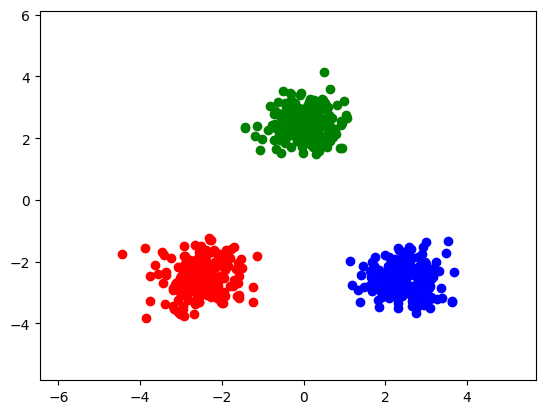

In [1]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import utils.training
import tqdm
import sys
import numpy as np
from importlib import reload
import LinearSampling.Posteriors as lsp
torch.set_default_dtype(torch.float64)

# grid : X1 x X2: [-4,4] x [-4,4]
# C1: mu = (-2.5, -2.5), C2: mu = (0,2.5), C3: mu = (2.5,-2.5)

mu = torch.tensor([[-2.5,-2.5],[0,2.5],[2.5,-2.5]])
sigma = 0.5

d = mu.shape[1]
ni = 200
C = 3
n = C * ni
train_x = torch.empty((n,d))
train_y = torch.empty((n,))

for idx in range(C):
    train_x[idx*ni:(idx+1)*ni] = torch.randn((ni,d))*sigma + mu[idx]
    train_y[idx*ni:(idx+1)*ni] = idx
train_y.to(dtype=torch.long)

xlim = train_x[:,0].min() - 2,train_x[:,0].max() + 2; ylim = train_x[:,1].min() -2 ,train_x[:,1].max() + 2

colors = ['r','g','b']
f,ax = plt.subplots()
for c in range(C):
    xc = train_x[train_y==c]
    ax.scatter(xc[:,0].numpy(),xc[:,1].numpy(),color=colors[c])
ax.set_xlim(xlim)
ax.set_ylim(ylim)

test_sample = 1000
Mx,My = torch.meshgrid(torch.linspace(xlim[0],xlim[1],100),torch.linspace(ylim[0],ylim[1],test_sample))
test_x = torch.stack([Mx.reshape(-1),My.reshape(-1)],dim=1)

In [4]:
n_test = 500

xx, yy = np.meshgrid(
    np.linspace(xlim[0], xlim[1], n_test), np.linspace(ylim[0], ylim[1], n_test)
)

test_grid_points = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).to(
    torch.float64
)

| Epoch [999/1000] Loss: 0.00013150 Acc@1: 100.000% GradNorm: 0.0009
Gradient norm : 0.0009037
Network parameter count: 1203


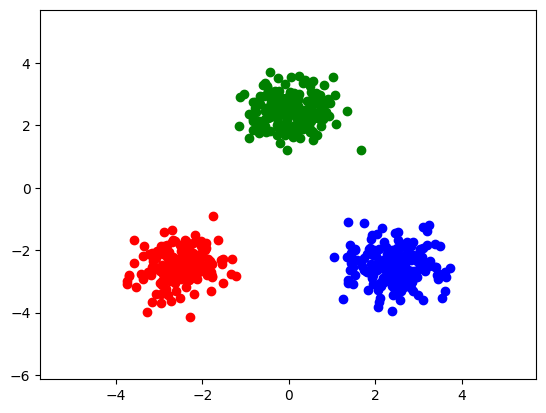

In [5]:
width = 200
epochs = 1000
lr = 0.01
wd = 0

# class smallmlp(torch.nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.linear1 = torch.nn.Linear(d, width)
#         self.act = torch.nn.SiLU()
#         self.linear2 = torch.nn.Linear(width, C)

#     def forward(self, x):
#         x = self.act(self.linear1(x))
#         return self.linear2(x)

# net = smallmlp()

net = torch.nn.Sequential(
            torch.nn.Linear(d, width),
            torch.nn.SiLU(),
            torch.nn.Linear(width, C)
        )

ce_loss = torch.nn.CrossEntropyLoss()
optim = torch.optim.SGD(net.parameters(), 
                        lr = lr, 
                        weight_decay=wd, 
                        momentum=0.9)

for epoch in range(epochs):
    pred = net(train_x)
    loss = ce_loss(pred, train_y.to(dtype=torch.long))

    optim.zero_grad()
    loss.backward()
    optim.step()
    

    acc = (pred.argmax(1) == train_y.to(dtype=torch.long)).type(torch.float).mean().item()

    total_norm = 0
    for p in net.parameters():
        param_norm = p.grad.data.norm(2)
        total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)

    sys.stdout.write('\r')
    sys.stdout.write('| Epoch [%3d/%3d] Loss: %.8f Acc@1: %.3f%% GradNorm: %.4f'
            %(epoch, epochs, loss.item(), acc*100, total_norm))
    sys.stdout.flush()

total_norm = 0
for p in net.parameters():
    param_norm = p.grad.data.norm(2)
    total_norm += param_norm.item() ** 2
total_norm = total_norm ** (1. / 2)
print(f'\nGradient norm : {total_norm:.4}')


colorsp = ['r','g','b']
f,ax = plt.subplots()
for c in range(C):
    xc = train_x[net(train_x).argmax(1) == c].detach()
    ax.scatter(xc[:,0].numpy(),xc[:,1].numpy(),color=colorsp[c])
ax.set_xlim(xlim)
ax.set_ylim(ylim)

num_weights = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"Network parameter count: {num_weights}")

In [6]:
from matplotlib import colors
def plot_predictions_classification(
    X_test,
    Y_test,
    y_pred,
    test_grid_points,
    sum_var = False,
    log_on = False,
    cut_off = None
) -> plt.Figure:
    """Plot the classification results and the associated uncertainty.

    Args:
        X_test: The input features.
        Y_test: The true labels.
        y_pred: The predicted labels.
        test_grid_points: The grid of test points.
        pred_uct: The uncertainty of the predictions.
    """
    fig, axs = plt.subplots(2, 2, figsize=(9, 9))
    cm = plt.cm.get_cmap("magma")

    grid_size = int(np.sqrt(test_grid_points.shape[0]))
    xx = test_grid_points[:, 0].reshape(grid_size, grid_size)
    yy = test_grid_points[:, 1].reshape(grid_size, grid_size)

    # Create a scatter plot of the input features, colored by the true labels
    axs[0][0].scatter(X_test[:, 0], X_test[:, 1], c=Y_test, cmap=cm, edgecolors="black")
    axs[0][0].set_title("True Labels")

    # Create a scatter plot of the input features, colored by the predicted labels
    prediction = y_pred.mean(0).argmax(-1)
    axs[0][1].imshow(
        prediction.reshape(grid_size, grid_size),
        alpha=0.8,
        cmap=cm,
        origin="lower",
        extent=[xx.min(), xx.max(), yy.min(), yy.max()],
        interpolation="bicubic",
        aspect="auto"
    )
    axs[0][1].scatter(X_test[:, 0], X_test[:, 1], c=Y_test, cmap=cm, edgecolors="black")
    axs[0][1].set_title("Predicted Labels")

    # Create a scatter plot of the input features, colored by the uncertainty
    if sum_var:
        unc = y_pred.var(0).sum(-1)
    else:
        unc = y_pred.var(0).max(-1)[0]
    if log_on:
        unc = torch.log(unc)
    unc -= unc.min()
    unc /= unc.max()
    if cut_off is not None:
        unc[unc > cut_off] = 1
    im2 = axs[1][0].imshow(
        unc.reshape(grid_size, grid_size),
        alpha=0.8,
        cmap=cm,
        origin="lower",
        extent=[xx.min(), xx.max(), yy.min(), yy.max()],
        interpolation="bicubic",
        aspect="auto",
    )
    axs[1][0].scatter(
        X_test[:, 0], X_test[:, 1], c=Y_test, cmap=cm, edgecolors="black"
    )
    axs[1][0].set_title("Uncertainty - Variance")
    fig.colorbar(im2, ax=axs[1][0], fraction=0.05, pad=0.008)

    # Create a scatter plot of the input features, colored by the uncertainty
    unc = 1 - y_pred.mean(0).max(-1)[0]
    im3 = axs[1][1].imshow(
        unc.reshape(grid_size, grid_size),
        alpha=0.8,
        cmap=cm,
        origin="lower",
        extent=[xx.min(), xx.max(), yy.min(), yy.max()],
        interpolation="bicubic",
        aspect="auto",
    )
    axs[1][1].scatter(
        X_test[:, 0], X_test[:, 1], c=Y_test, cmap=cm, edgecolors="black"
    )
    axs[1][1].set_title("Uncertainty - Confidence")
    fig.colorbar(im3, ax=axs[1][1], fraction=0.05, pad=0.008)

    return fig

In [7]:
from matplotlib import colors
def plot_var(
    X_test,
    Y_test,
    y_pred,
    test_grid_points,
    sum_var = False,
    log_on = False,
    cut_off = None
) -> plt.Figure:
    """Plot the classification results and the associated uncertainty.

    Args:
        X_test: The input features.
        Y_test: The true labels.
        y_pred: The predicted labels.
        test_grid_points: The grid of test points.
        pred_uct: The uncertainty of the predictions.
    """
    fig, axs = plt.subplots(1, 1, figsize=(4, 4))
    cm = plt.cm.get_cmap("plasma")

    grid_size = int(np.sqrt(test_grid_points.shape[0]))
    xx = test_grid_points[:, 0].reshape(grid_size, grid_size)
    yy = test_grid_points[:, 1].reshape(grid_size, grid_size)

    # Create a scatter plot of the input features, colored by the uncertainty
    if sum_var:
        unc = y_pred.var(0).sum(-1)
    else:
        unc = y_pred.var(0).max(-1)[0]
    if log_on:
        unc = torch.log(unc)
    unc -= unc.min()
    unc /= unc.max()
    if cut_off is not None:
        unc[unc > cut_off] = 1
    im2 = axs.imshow(
        unc.reshape(grid_size, grid_size),
        alpha=0.8,
        cmap=cm,
        origin="lower",
        extent=[xx.min(), xx.max(), yy.min(), yy.max()],
        interpolation="bicubic",
        aspect="auto",
    )
    axs.scatter(
        X_test[:, 0], X_test[:, 1], c=Y_test, cmap=cm, edgecolors="black"
    )
    # axs.set_title("Uncertainty - Variance")
    fig.colorbar(im2, ax=axs, fraction=0.05, pad=0.008)
    return fig

In [8]:
class toy_dataset(Dataset):
    def __init__(self,x,y):
        self.x = x
        self.y = y

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, i):
        return self.x[i].to(dtype=torch.float64), self.y[i].to(dtype=torch.long)

In [9]:
pred_dict = {}

### DNN-GLM

In [11]:
reload(lsp)

dnn_glm = lsp.Posterior(network=net,
                        glm_type='DNN',
                        task='classification',
                        precision='double')

gamma = 12
res = dnn_glm.train(train=toy_dataset(train_x,train_y),
                    bs=n,
                    gamma=gamma,
                    S=100,
                    lr=1e-2,
                    epochs=1000,
                    mu=0.9,
                    verbose=True)

predictions_dnn = dnn_glm.test(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)
pred_dict['DNN-GLM'] = predictions_dnn

100%|██████████| 1000/1000 [00:16<00:00, 59.39it/s, mean_sq_loss=2.74, mean_ce_loss=0.00529, mean_accuracy=0.998, mean_grad_norm=1.25, gpu_mem=0] 


Linear sampling training complete.
{'sq_loss': [[23794.704259781905], [15212.847802465558], [5896.780311139653], [2453.5745952494226], [4888.739539998064], [8391.63938390612], [8957.253035230808], [6726.974860283397], [4527.235701940948], [4254.457350645825], [5179.606629697495], [5379.552176608192], [4101.412184848606], [2406.1881473373705], [1751.8796082096783], [2369.7487378007913], [3169.099444196725], [3034.6528126519943], [1973.0311620434318], [961.8621532130866], [843.2749125071418], [1505.1461615815322], [2111.826421849813], [1995.908933790416], [1248.9212286312618], [506.33245095880983], [278.24923462990193], [533.7992624270126], [863.1252236726648], [933.9203618044933], [753.0684607269435], [545.43730103463], [468.83078609449274], [482.8214350409518], [457.05721448492426], [345.4988668517505], [228.22124958957588], [203.51901009072844], [273.1358374617451], [344.80474855668547], [333.3094607536195], [242.7421982758765], [150.04404835553032], [121.15342820474787], [152.0124930

### LL-GLM

In [13]:
reload(lsp)

ll_glm = lsp.Posterior(network=net,
                        glm_type='LL',
                        task='classification',
                        precision='double')

gamma = 27
res = ll_glm.train(train=toy_dataset(train_x,train_y),
                    bs=n,
                    gamma=gamma,
                    S=100,
                    lr=3e-2,
                    epochs=1000,
                    mu=0.9,
                    verbose=True)

predictions_ll = ll_glm.test(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)
pred_dict['LL-GLM'] = predictions_ll

Full-batch Jacobian pre-computed for linear sampling posterior.


100%|██████████| 1000/1000 [00:12<00:00, 80.80it/s, mean_sq_loss=5.04, mean_ce_loss=0.0454, mean_accuracy=0.991, mean_grad_norm=0.867, gpu_mem=0] 


Linear sampling training complete.


### DE

In [36]:
from posteriors.de import DeepEnsemble
from torch.utils.data import DataLoader

train_loader = DataLoader(toy_dataset(train_x,train_y), n)
test_loader = DataLoader(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)

de_posterior = DeepEnsemble(network=net, task='classification', M = 10)
train_nll, train_acc = de_posterior.train(loader=train_loader, 
                                        lr=lr, 
                                        wd=wd,
                                        epochs=epochs, 
                                        optim_name='sgd', 
                                        sched_name=None, 
                                        verbose=True,
                                        extra_verbose=False)

predictions_de = de_posterior.test(test_loader)
pred_dict['DE'] = predictions_de

100%|██████████| 10/10 [01:06<00:00,  6.66s/it, train nll=0.000792, train mse=1]


### BDE

In [37]:
from posteriors.bde import BayesianDeepEnsemble

train_loader = DataLoader(toy_dataset(train_x,train_y), n)
test_loader = DataLoader(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)

bde_posterior = BayesianDeepEnsemble(network=net, M = 10, num_classes=3)
train_nll, train_acc = bde_posterior.train(loader=train_loader, 
                                        lr=lr, 
                                        wd=wd,
                                        epochs=epochs, 
                                        optim_name='sgd', 
                                        sched_name=None, 
                                        verbose=True,
                                        extra_verbose=False)

predictions_bde = bde_posterior.test(test_loader)
pred_dict['BDE'] = predictions_bde

100%|██████████| 10/10 [01:18<00:00,  7.84s/it, Brier Loss=6.72e-10, Acc=1]


### LLA

In [38]:
from laplace import Laplace

train_loader = DataLoader(toy_dataset(train_x,train_y), n)
test_loader = DataLoader(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)

la = Laplace(net, "classification",
            subset_of_weights="all",
            hessian_structure="full")
la.fit(train_loader)
la.optimize_prior_precision(
    method="marglik",
    pred_type='glm',
    link_approx='probit',
    progress_bar=True
)

predictions = []
T = 100
for x,_ in test_loader:
    predictions.append(la.predictive_samples(x=x,pred_type='glm',n_samples=T).detach()) # output is (samples x batchsize x output)
predictions_lla = torch.cat(predictions,dim=1)
pred_dict['LLA'] = predictions_lla

c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\laplace\baselaplace.py:435: UserWarning: By default `link_approx` is `probit`. Make sure to set it equals to the way you want to call `la(test_data, pred_type=..., link_approx=...)`.
  warnings.warn(
[Optimizing marginal likelihood]: 100%|██████████| 100/100 [00:02<00:00, 34.03it/s]


### SWAG

In [39]:
import posteriors.swag as swag

train_loader = DataLoader(toy_dataset(train_x,train_y), n)
test_loader = DataLoader(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)

swag_net = swag.SWAG(net=net,
                    epochs=epochs,
                    lr=lr*1e2, 
                    cov_mat = True,
                    max_num_models=100, 
                    wd=wd)

swag_net.train_swag(train_dataloader=train_loader,progress_bar=True)

predictions_swag = swag_net.test(loader=test_loader, samples=10)
pred_dict['SWAG'] = predictions_swag

100%|██████████| 10/10 [00:23<00:00,  2.37s/it]


### SGLD

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 4 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 4:   0%|          | 0/1 [00:00<?, ?it/s, v_num=2, train_loss=2.3e-5]          

c:\Users\s4531973\Documents\PhD\Code\ll_uq\posteriors\sgld.py:95: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.stack([torch.tensor(item[1]) for item in batch])


Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 125.23it/s, v_num=2, train_loss=1.7e-5]  

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 44.31it/s, v_num=2, train_loss=1.7e-5] 


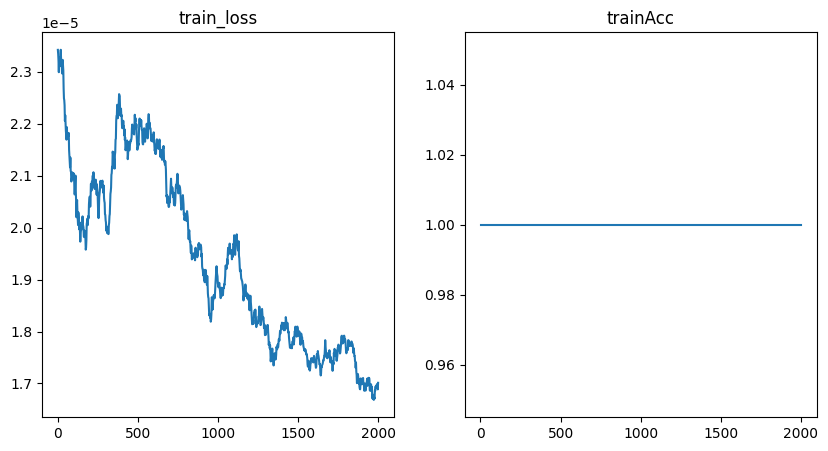

In [40]:
import posteriors.sgld as sgld
from importlib import reload; reload(sgld)

slgd_posterior = sgld.sgld(net=net,
                           loss_fn=torch.nn.CrossEntropyLoss(),
                           lr=2e-1,
                           lr_final=1e-1,
                           max_itr=epochs,
                           wd=wd,
                           nf=1e-3,
                           epochs=epochs,
                           S=100,
                           res_dir='results/sgld/')

slgd_posterior.train(toy_dataset(train_x,train_y), 
                     toy_dataset(test_grid_points,torch.ones(test_grid_points.shape[0])), n, plot_loss=True)

test_loader = DataLoader(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)
predictions_sgld = slgd_posterior.test(test_loader)
pred_dict['SGLD'] = predictions_sgld

### SNGP

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 2 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 4: 100%|██████████| 1/1 [00:00<00:00, 41.37it/s, v_num=2]

c:\Users\s4531973\Documents\PhD\Code\ll_uq\posteriors\sngp.py:121: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.stack([torch.tensor(item[1]) for item in batch])


Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 35.07it/s, v_num=2] 

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 22.18it/s, v_num=2]


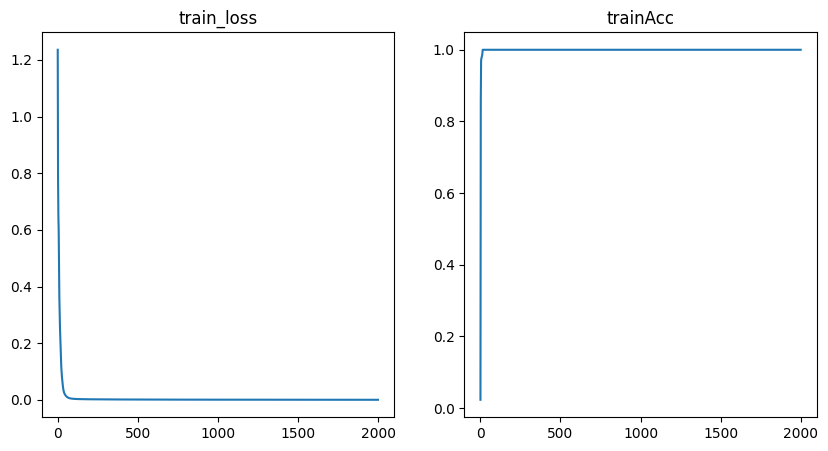

In [41]:
import posteriors.sngp as sngp
from importlib import reload; reload(sngp)

sngp_posterior = sngp.SNGP(network=net,
                           num_classes=3,
                           input_size=2,
                           T=100,
                           loss_fn=torch.nn.CrossEntropyLoss(),
                           lr=lr,
                           wd=wd,
                           epochs=epochs,
                           optim='sgd',
                           res_dir='results/sngp/')

sngp_posterior.train(toy_dataset(train_x,train_y), 
                     toy_dataset(test_grid_points,torch.ones(test_grid_points.shape[0])), n, plot_loss=True)

test_loader = DataLoader(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)
predictions = []
T = 100
for x,_ in test_loader:
    predictions.append(sngp_posterior.eval(x=x).detach()) # output is (samples x batchsize x output)
predictions_sngp = torch.cat(predictions, dim=1)  # output is (samples x batchsize x output)
pred_dict['SNGP'] = predictions_sngp

### MC-Dropout

In [42]:
import posteriors.mc as mc
from importlib import reload; reload(mc)

dropout_posterior = mc.MCDropout(network=net,
                                 p=0.1)

test_loader = DataLoader(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)
predictions_mc = dropout_posterior.test(test_loader, samples=10)
pred_dict['MC'] = predictions_mc

### Plot Variance

C:\Users\s4531973\AppData\Local\Temp\ipykernel_26668\3811855055.py:32: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  f.subplots_adjust(wspace=0, hspace=0)
C:\Users\s4531973\AppData\Local\Temp\ipykernel_26668\3811855055.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


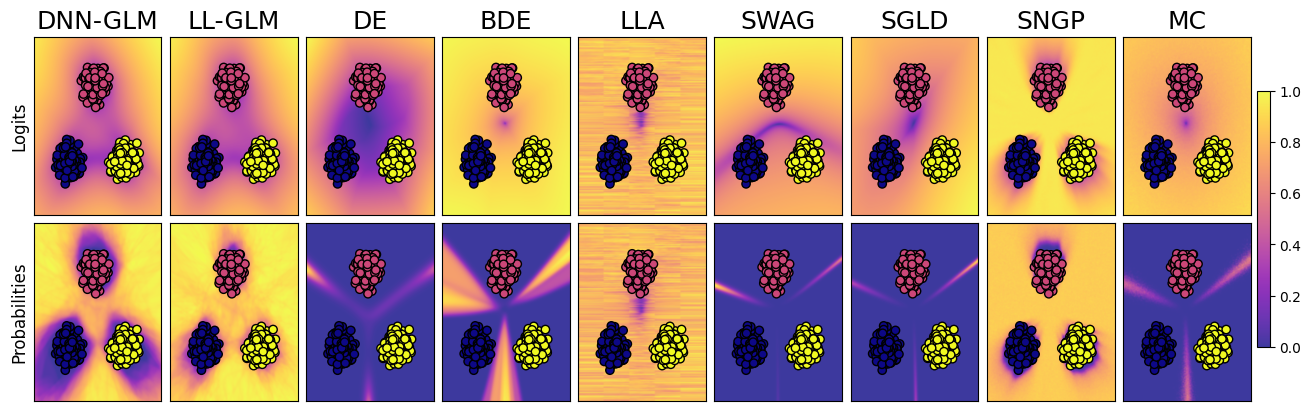

In [43]:
import utils.metrics as metrics
from importlib import reload; reload(metrics)

keys = list(pred_dict.keys())

fs, h, w = 18, 4, 13

f, axes = plt.subplots(2, len(pred_dict.keys()), figsize=(w, h), sharex=True, sharey=True, layout='constrained')

for idk,ax in enumerate(axes.T):
    for i in range(2):    
        ax[i], im = metrics.plot_var_ax(
            X_test=train_x,
            Y_test=train_y,
            y_pred=pred_dict[keys[idk]],
            test_grid_points=test_grid_points,
            ax=ax[i],
            logit=(i == 0),
            sigmoid_on=(C == 1),
            cut_off=None
        )
        if idk == 0:
            ax[0].set_ylabel('Logits', fontsize=int(fs * 2/3))
            ax[1].set_ylabel('Probabilities', fontsize=int(fs * 2/3))
        if i == 0:
            ax[i].set_title(keys[idk], fontsize=fs)
        ax[i].set_xticks([], [])  
        ax[i].set_yticks([], [])  


f.colorbar(im, ax=axes.T[-1], fraction=0.1, pad=0.05)
f.subplots_adjust(wspace=0, hspace=0)
f.show()
f.savefig(f'results/toy_classification/three_islands.pdf', format='pdf')

### Plot Variance (GLMs)

C:\Users\s4531973\AppData\Local\Temp\ipykernel_10024\4139289416.py:37: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  f.subplots_adjust(wspace=0, hspace=0)
C:\Users\s4531973\AppData\Local\Temp\ipykernel_10024\4139289416.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


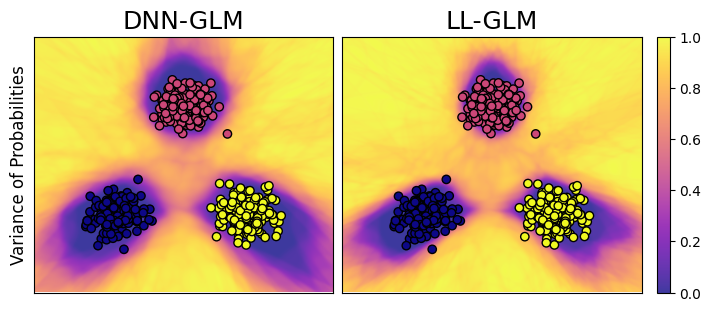

In [14]:
# Excerpt to plot only variance of probabilities for LL-GLM and DNN-GLM

import utils.metrics as metrics
from importlib import reload; reload(metrics)

pred_dict_glms = {'DNN-GLM': pred_dict['DNN-GLM'],
                  'LL-GLM': pred_dict['LL-GLM']
                  }

keys = list(pred_dict_glms.keys())

fs, h, w = 18, 3, 7

f, axes = plt.subplots(1, len(pred_dict_glms.keys()), figsize=(w, h), sharex=True, sharey=True, layout='constrained')
for idk,ax in enumerate(axes.T):
    for i in range(1):    
        ax, im = metrics.plot_var_ax(
            X_test=train_x,
            Y_test=train_y,
            y_pred=pred_dict_glms[keys[idk]],
            test_grid_points=test_grid_points,
            ax=ax,
            logit=False,
            sigmoid_on=(C == 1),
            cut_off=None
        )
        if idk == 0:
            # ax[0].set_ylabel('Logits', fontsize=int(fs * 2/3))
            ax.set_ylabel('Variance of Probabilities', fontsize=int(fs * 2/3))
        if i == 0:
            ax.set_title(keys[idk], fontsize=fs)
        ax.set_xticks([], [])  
        ax.set_yticks([], [])  


f.colorbar(im, ax=axes.T[-1], fraction=0.1, pad=0.05)
f.subplots_adjust(wspace=0, hspace=0)
f.show()
f.savefig(f'results/toy_classification/three_islands_glms.pdf', format='pdf')

# Two Moons

### Functions

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from importlib import reload

def plot_two_moons_data(
    X_train: np.ndarray, Y_train: np.ndarray, X_val: np.ndarray, y_val: np.ndarray
) -> plt.Figure:
    """Plot the two moons dataset.

    Args:
        X_train: Training data features
        Y_train: Training data labels
        X_val: Validation data features
        y_val: Validation data labels

    Returns:
        figure of two moons dataset
    """
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Plot training data
    axs[0].scatter(X_train[:, 0], X_train[:, 1], c=Y_train, cmap="viridis")
    axs[0].set_title("Training Set")

    # Plot validation data
    axs[1].scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap="viridis")
    axs[1].set_title("Validation Set")

    return fig

def plot_predictions_classification(
    X_test: np.ndarray,
    Y_test: np.ndarray,
    y_pred: np.ndarray,
    test_grid_points,
    pred_uct: np.ndarray | None = None,
) -> plt.Figure:
    """Plot the classification results and the associated uncertainty.

    Args:
        X_test: The input features.
        Y_test: The true labels.
        y_pred: The predicted labels.
        test_grid_points: The grid of test points.
        pred_uct: The uncertainty of the predictions.
    """
    num_cols = 3 if pred_uct is not None else 2

    fig, axs = plt.subplots(1, num_cols, figsize=(num_cols * 6, 6))
    cm = plt.cm.get_cmap("plasma")

    grid_size = int(np.sqrt(test_grid_points.shape[0]))
    xx = test_grid_points[:, 0].reshape(grid_size, grid_size)
    yy = test_grid_points[:, 1].reshape(grid_size, grid_size)

    # Create a scatter plot of the input features, colored by the true labels
    axs[0].scatter(X_test[:, 0], X_test[:, 1], c=Y_test, cmap=cm, edgecolors="black")
    axs[0].set_title("True Labels")

    # Create a scatter plot of the input features, colored by the predicted labels
    axs[1].imshow(
        y_pred.reshape(grid_size, grid_size),
        alpha=0.8,
        cmap=cm,
        origin="lower",
        extent=[xx.min(), xx.max(), yy.min(), yy.max()],
        interpolation="bicubic",
        aspect="auto",
    )
    axs[1].scatter(X_test[:, 0], X_test[:, 1], c=Y_test, cmap=cm, edgecolors="black")
    axs[1].set_title("Predicted Labels")

    if pred_uct is not None:
        # Create a scatter plot of the input features, colored by the uncertainty
        im2 = axs[2].imshow(
            pred_uct.reshape(grid_size, grid_size),
            alpha=0.8,
            cmap=cm,
            origin="lower",
            extent=[xx.min(), xx.max(), yy.min(), yy.max()],
            interpolation="bicubic",
            aspect="auto",
        )
        axs[2].scatter(
            X_test[:, 0], X_test[:, 1], c=Y_test, cmap=cm, edgecolors="black"
        )
        axs[2].set_title("Uncertainty")
        fig.colorbar(im2, ax=axs[2], fraction=0.05, pad=0.008)

    return fig

from matplotlib import colors

def plot_var(
    X_test,
    Y_test,
    y_pred,
    test_grid_points,
    sum_var = False,
    log_on = False,
    cut_off = None,
    alpha = 1
) -> plt.Figure:
    """Plot the classification results and the associated uncertainty.

    Args:
        X_test: The input features.
        Y_test: The true labels.
        y_pred: The predicted labels.
        test_grid_points: The grid of test points.
        pred_uct: The uncertainty of the predictions.
    """
    fig, axs = plt.subplots(1, 1, figsize=(4, 4))
    cm = plt.cm.get_cmap("plasma")

    grid_size = int(np.sqrt(test_grid_points.shape[0]))
    xx = test_grid_points[:, 0].reshape(grid_size, grid_size)
    yy = test_grid_points[:, 1].reshape(grid_size, grid_size)

    # Create a scatter plot of the input features, colored by the uncertainty
    if sum_var:
        unc = y_pred.var(0).sum(-1)
    else:
        unc = y_pred.var(0).max(-1)[0]
    if log_on:
        unc = torch.log(unc)
    unc -= unc.min()
    unc /= unc.max()
    if cut_off is not None:
        unc[unc > cut_off] = 1
    im2 = axs.imshow(
        unc.reshape(grid_size, grid_size),
        alpha=0.8,
        cmap=cm,
        origin="lower",
        extent=[xx.min(), xx.max(), yy.min(), yy.max()],
        interpolation="bicubic",
        aspect="auto",
    )
    axs.scatter(
        X_test[:, 0], X_test[:, 1], c=Y_test, cmap=cm, edgecolors="black", alpha=alpha
    )
    # axs.set_title("Uncertainty - Variance")
    fig.colorbar(im2, ax=axs, fraction=0.05, pad=0.008)
    return fig

class toy_dataset(Dataset):
    def __init__(self,x,y):
        self.x = x
        self.y = y

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, i):
        return self.x[i].to(dtype=torch.float64), self.y[i].to(dtype=torch.long)


### Setup / Network

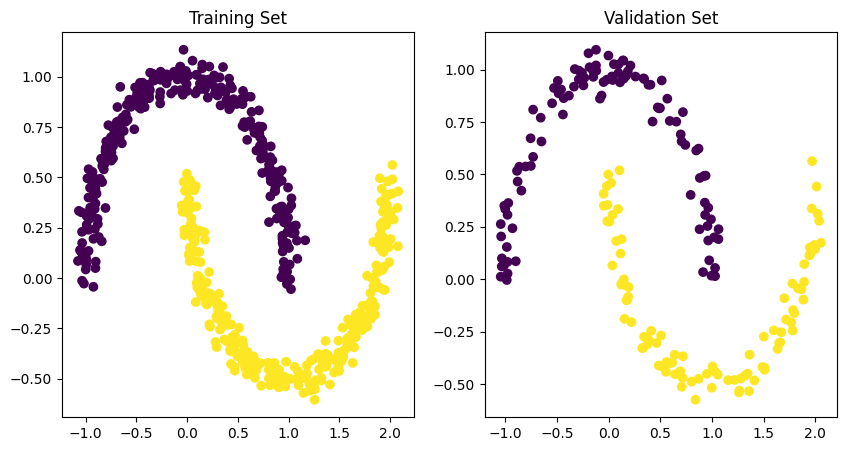

In [16]:
from importlib import reload
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch
import sys
import numpy as np
set_dtype = torch.float64
torch.set_default_dtype(torch.float64)

n = 1000
batch_size = 128
C = 1

# Generate the half-moon dataset
X, y = make_moons(n_samples=n, noise=0.05, random_state=0)
min_x0, max_x0 = X[:, 0].min(), X[:, 0].max()
min_x1, max_x1 = X[:, 1].min(), X[:, 1].max()

X_tensor = torch.tensor(X, dtype=set_dtype)
y_tensor = torch.tensor(y, dtype=torch.long)

# Split the dataset into training, validation, and test sets
X_temp, X_test, Y_temp, Y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.25
)

# Create a grid of test points
x_min, x_max = min_x0 - 1, max_x0 + 1
y_min, y_max = min_x1 - 1, max_x1 + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100)
)

test_grid_points = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).to(set_dtype)

def collate_fn_tensordataset(batch):
    """Collate function for tensor dataset to our framework."""
    inputs = torch.stack([item[0] for item in batch])
    targets = torch.stack([item[1] for item in batch])
    return {"input": inputs, "target": targets}

train_dataset = TensorDataset(X_train, Y_train)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn_tensordataset,
)

val_dataset = TensorDataset(X_val.double(), Y_val)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn_tensordataset,
)

test_dataset = TensorDataset(X_test.double(), Y_test)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn_tensordataset,
)

fig = plot_two_moons_data(X_train, Y_train, X_test, Y_test)

Network parameter count: 801
| Epoch [2999/3000] Loss: 0.00099364 Acc@1: 100.000% GradNorm: 0.0007
Gradient norm : 0.0006807


C:\Users\s4531973\AppData\Local\Temp\ipykernel_10024\1419744638.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap("plasma")


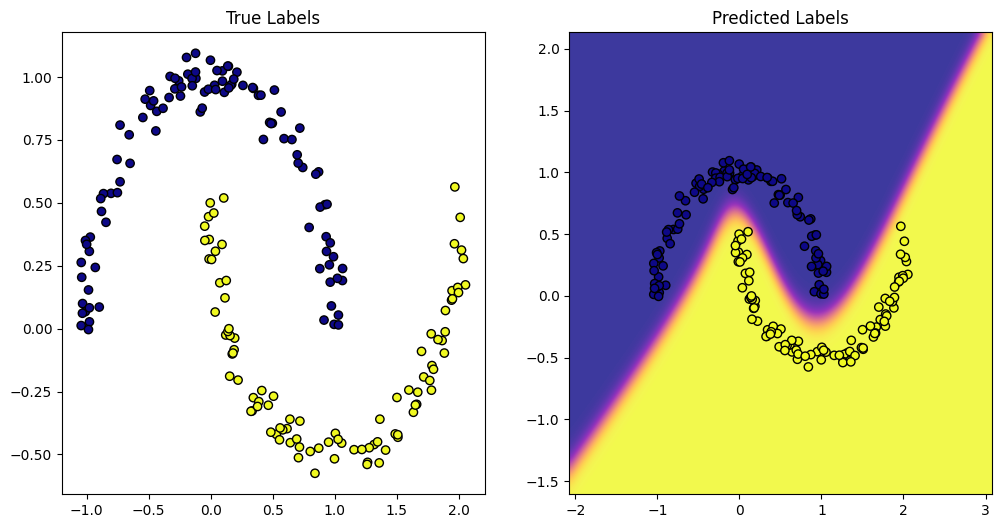

In [17]:
width = 200
epochs = 3000
lr = 0.1
wd = 0.000
d = 2
C = 1

net = torch.nn.Sequential(
            torch.nn.Linear(d, width),
            torch.nn.SiLU(),
            torch.nn.Linear(width, C),
        )
net.to(dtype=set_dtype)
num_weights = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"Network parameter count: {num_weights}")
    
# ce_loss = torch.nn.CrossEntropyLoss()
ce_loss = torch.nn.BCEWithLogitsLoss()
optim = torch.optim.SGD(net.parameters(), 
                        lr = lr, 
                        weight_decay=wd, 
                        momentum=0.9)

for epoch in range(epochs):
    pred = net(X_train)
    loss = ce_loss(pred, Y_train.to(dtype=torch.float64).unsqueeze(1))

    optim.zero_grad()
    loss.backward()
    optim.step()
    

    acc = (pred.sigmoid().round().squeeze(1) == Y_train).type(torch.float).mean().item()

    total_norm = 0
    for p in net.parameters():
        param_norm = p.grad.data.norm(2)
        total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)

    sys.stdout.write('\r')
    sys.stdout.write('| Epoch [%3d/%3d] Loss: %.8f Acc@1: %.3f%% GradNorm: %.4f'
            %(epoch, epochs, loss.item(), acc*100, total_norm))
    sys.stdout.flush()

net_loss = loss

total_norm = 0
for p in net.parameters():
    param_norm = p.grad.data.norm(2)
    total_norm += param_norm.item() ** 2
total_norm = total_norm ** (1. / 2)
print(f'\nGradient norm : {total_norm:.4}')

fig = plot_predictions_classification(
    X_test,
    Y_test,
    net(test_grid_points).sigmoid().detach(),
    test_grid_points
)

### Setup Prediction Dict

In [18]:
pred_dict = {}

### DNN-GLM

In [26]:
reload(lsp)

dnn_glm = lsp.Posterior(network=net,
                        glm_type='DNN',
                        task='classification',
                        precision='double')

gamma = 30
res = dnn_glm.train(train=train_dataset,
                    bs=n,
                    gamma=gamma,
                    S=100,
                    lr=1e-2,
                    epochs=1000,
                    mu=0.9,
                    verbose=True)

predictions_dnn = dnn_glm.test(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)
pred_dict['DNN-GLM'] = predictions_dnn

Full-batch Jacobian pre-computed for linear sampling posterior.


100%|██████████| 1000/1000 [00:06<00:00, 154.73it/s, mean_sq_loss=8.16, mean_ce_loss=0.029, mean_accuracy=0.99, mean_grad_norm=2.06, gpu_mem=0]    


Linear sampling training complete.


### LL-GLM

In [35]:
reload(lsp)

ll_glm = lsp.Posterior(network=net,
                        glm_type='LL',
                        task='classification',
                        precision='double')

gamma = 80
res = ll_glm.train(train=train_dataset,
                    bs=n,
                    gamma=gamma,
                    S=100,
                    lr=1e-2,
                    epochs=1000,
                    mu=0.9,
                    verbose=True)

predictions_ll = ll_glm.test(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)
pred_dict['LL-GLM'] = predictions_ll

Full-batch Jacobian pre-computed for linear sampling posterior.


100%|██████████| 1000/1000 [00:05<00:00, 192.16it/s, mean_sq_loss=28.8, mean_ce_loss=0.201, mean_accuracy=0.949, mean_grad_norm=4.09, gpu_mem=0]   


Linear sampling training complete.


### DE

In [19]:
from posteriors.de import DeepEnsemble
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, n)
test_loader = DataLoader(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)

de_posterior = DeepEnsemble(network=net, task='classification', M = 10, target = 'binary')
train_nll, train_acc = de_posterior.train(loader=train_loader, 
                                        lr=lr, 
                                        wd=wd,
                                        epochs=epochs, 
                                        optim_name='sgd', 
                                        sched_name=None, 
                                        verbose=True,
                                        extra_verbose=False)

predictions_de = de_posterior.test(test_loader)
pred_dict['DE'] = predictions_de

100%|██████████| 10/10 [02:01<00:00, 12.12s/it, train nll=0.00277, train mse=1]  


### BDE

In [20]:
from posteriors.bde import BayesianDeepEnsemble

train_loader = DataLoader(train_dataset, n)
test_loader = DataLoader(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)

bde_posterior = BayesianDeepEnsemble(network=net, M = 10, num_classes=1, target='binary')
train_nll, train_acc = bde_posterior.train(loader=train_loader, 
                                        lr=lr, 
                                        wd=wd,
                                        epochs=epochs, 
                                        optim_name='sgd', 
                                        sched_name=None, 
                                        verbose=True,
                                        extra_verbose=False)

predictions_bde = bde_posterior.test(test_loader)
pred_dict['BDE'] = predictions_bde

100%|██████████| 10/10 [02:39<00:00, 15.99s/it, Brier Loss=5.72e-5, Acc=1]


### SWAG

In [21]:
import posteriors.swag as swag; reload(swag)

train_loader = DataLoader(train_dataset, n)
test_loader = DataLoader(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)

swag_net = swag.SWAG(net=net,
                    epochs=epochs,
                    lr=lr*1e2, 
                    cov_mat = True,
                    max_num_models=100, 
                    wd=wd,
                    target='binary')

swag_net.train_swag(train_dataloader=train_loader,progress_bar=True)

predictions_swag = swag_net.test(loader=test_loader, samples=10)
pred_dict['SWAG'] = predictions_swag

100%|██████████| 10/10 [00:00<00:00, 10.43it/s]


### SGLD

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 4 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 6: 100%|██████████| 1/1 [00:00<00:00, 63.00it/s, v_num=1, train_loss=0.00371]

c:\Users\s4531973\Documents\PhD\Code\ll_uq\posteriors\sgld.py:95: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.stack([torch.tensor(item[1]) for item in batch])


Epoch 2999: 100%|██████████| 1/1 [00:00<00:00, 69.71it/s, v_num=1, train_loss=0.00156]  

`Trainer.fit` stopped: `max_epochs=3000` reached.


Epoch 2999: 100%|██████████| 1/1 [00:00<00:00, 44.30it/s, v_num=1, train_loss=0.00156]


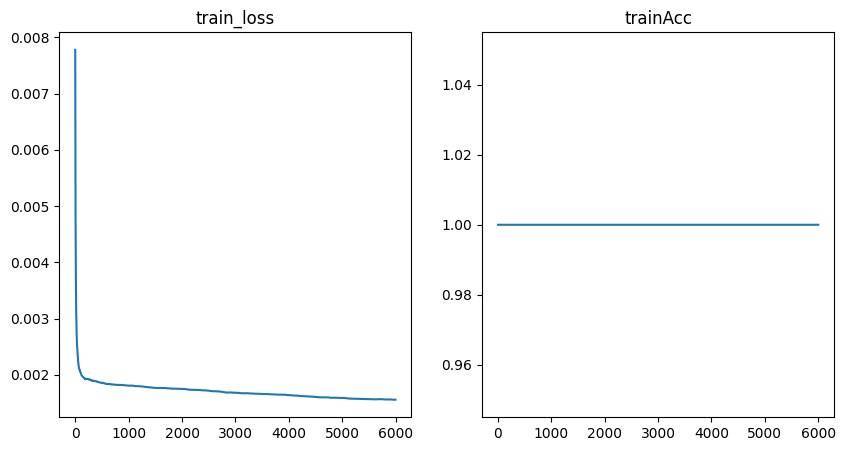

In [22]:
import posteriors.sgld as sgld
reload(sgld)

slgd_posterior = sgld.sgld(net=net,
                           loss_fn=torch.nn.BCEWithLogitsLoss(),
                           lr=2e-1,
                           lr_final=1e-1,
                           max_itr=epochs,
                           wd=wd,
                           nf=1e-3,
                           epochs=epochs,
                           S=100,
                           res_dir='results/sgld/')

slgd_posterior.train(train_dataset, 
                     toy_dataset(test_grid_points,torch.ones(test_grid_points.shape[0])), n, plot_loss=True)

test_loader = DataLoader(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)
predictions = []
T = 100
for x,_ in test_loader:
    predictions.append(slgd_posterior.eval(x=x).detach()) # output is (batchsize x output x samples)
predictions_sgld = torch.cat(predictions, dim=0).permute(2,0,1)  # output is (samples x batchsize x output)
pred_dict['SGLD'] = predictions_sgld

### SNGP

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 4:   0%|          | 0/1 [00:00<?, ?it/s, v_num=1]        

c:\Users\s4531973\Documents\PhD\Code\ll_uq\posteriors\sngp.py:121: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.stack([torch.tensor(item[1]) for item in batch])


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 32.85it/s, v_num=1]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 28.54it/s, v_num=1]


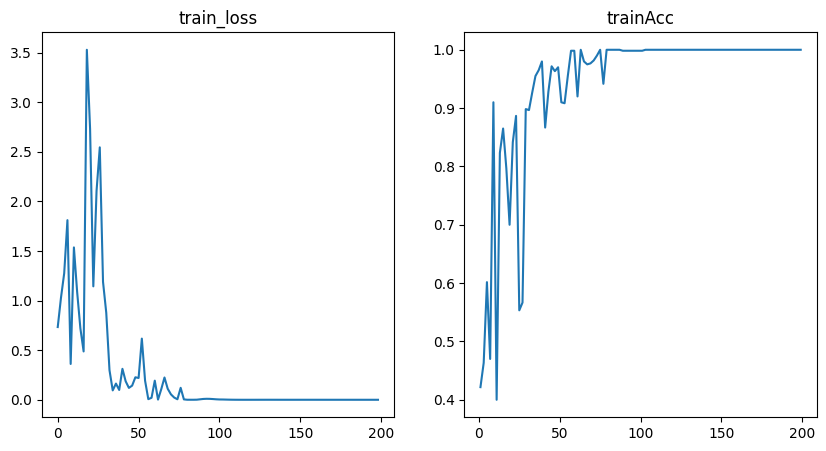

In [23]:
import posteriors.sngp as sngp
from importlib import reload; reload(sngp)

net_sngp = torch.nn.Sequential(
            torch.nn.Linear(d, width),
            torch.nn.SiLU(),
            torch.nn.Linear(width, C),
        )

sngp_posterior = sngp.SNGP(network=net_sngp,
                           num_classes=2,
                           input_size=2,
                           T=100,
                           loss_fn=torch.nn.CrossEntropyLoss(),
                           lr=lr,
                           wd=wd,
                           epochs=100,
                           optim='adam',
                           res_dir='results/sngp/')

sngp_posterior.train(train_dataset, 
                     toy_dataset(test_grid_points,torch.ones(test_grid_points.shape[0])), n, plot_loss=True)

test_loader = DataLoader(toy_dataset(test_grid_points,torch.ones(test_grid_points.shape)), 200)
predictions = []
T = 100
for x,_ in test_loader:
    predictions.append(sngp_posterior.eval(x=x.to(set_dtype)).detach()) # output is (samples x batchsize x output)
predictions_sngp = torch.cat(predictions, dim=1)  # output is (samples x batchsize x output)
pred_dict['SNGP'] = predictions_sngp

### MC-Dropout

In [24]:
import posteriors.mc as mc
from importlib import reload; reload(mc)

dropout_posterior = mc.MCDropout(network=net,
                                 p=0.1)

test_loader = DataLoader(toy_dataset(test_grid_points.to(set_dtype),torch.ones(test_grid_points.shape)), 200)
predictions_mc = dropout_posterior.test(test_loader, samples=10)
pred_dict['MC'] = predictions_mc

### Plot Variance

C:\Users\s4531973\AppData\Local\Temp\ipykernel_26668\1459314541.py:33: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  f.subplots_adjust(wspace=0, hspace=0)
C:\Users\s4531973\AppData\Local\Temp\ipykernel_26668\1459314541.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


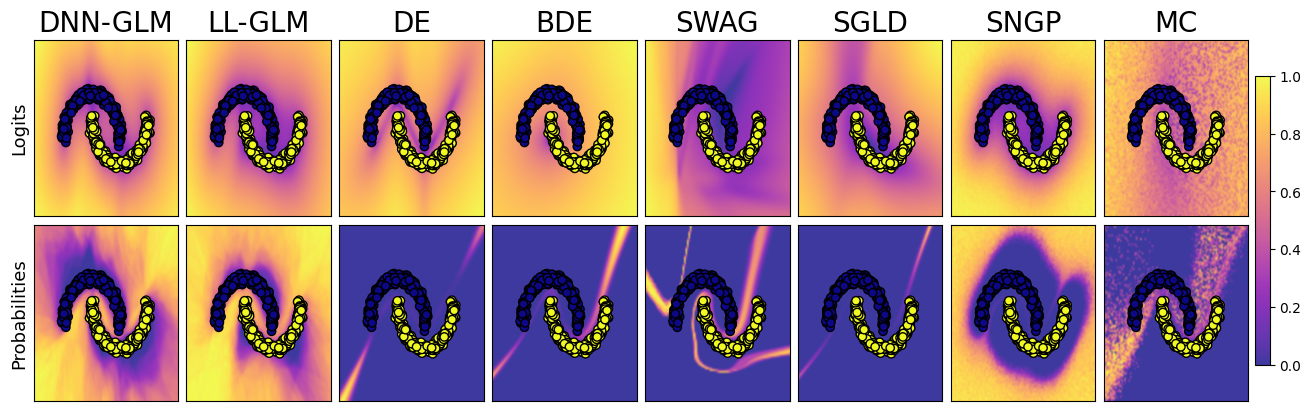

In [25]:
import utils.metrics as metrics
from importlib import reload; reload(metrics)

keys = list(pred_dict.keys())

fs, h, w = 20, 4, 13

f, axes = plt.subplots(2, len(pred_dict.keys()), figsize=(w, h), sharex=True, sharey=True, layout='constrained')

for idk,ax in enumerate(axes.T):
    for i in range(2):    
        ax[i], im = metrics.plot_var_ax(
            X_test=X_train,
            Y_test=Y_train,
            y_pred=pred_dict[keys[idk]],
            test_grid_points=test_grid_points,
            ax=ax[i],
            logit=(i == 0),
            sigmoid_on=(C == 1),
            cut_off=None,
            log_true=True,
            alpha=1
        )
        if idk == 0:
            ax[0].set_ylabel('Logits', fontsize=int(fs * 2/3))
            ax[1].set_ylabel('Probabilities', fontsize=int(fs * 2/3))
        if i == 0:
            ax[i].set_title(keys[idk], fontsize=fs)
        ax[i].set_xticks([], [])  
        ax[i].set_yticks([], [])  

f.colorbar(im, ax=axes.T[-1], fraction=0.1, pad=0.05)
f.subplots_adjust(wspace=0, hspace=0)
f.show()
f.savefig(f'results/toy_classification/twomoons.pdf', format='pdf')

### Plot Variance (GLMs)

C:\Users\s4531973\AppData\Local\Temp\ipykernel_10024\2037696954.py:38: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  f.subplots_adjust(wspace=0, hspace=0)
C:\Users\s4531973\AppData\Local\Temp\ipykernel_10024\2037696954.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


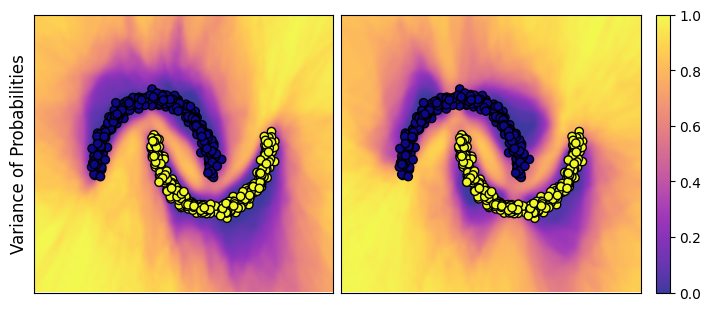

In [36]:
# Excerpt to plot only variance of probabilities for LL-GLM and DNN-GLM

import utils.metrics as metrics
from importlib import reload; reload(metrics)

pred_dict_glms = {'DNN-GLM': pred_dict['DNN-GLM'],
                  'LL-GLM': pred_dict['LL-GLM']
                  }

keys = list(pred_dict_glms.keys())

fs, h, w = 18, 3, 7

f, axes = plt.subplots(1, len(pred_dict_glms.keys()), figsize=(w, h), sharex=True, sharey=True, layout='constrained')
for idk,ax in enumerate(axes.T):
    for i in range(1):    
        ax, im = metrics.plot_var_ax(
            X_test=X_train,
            Y_test=Y_train,
            y_pred=pred_dict_glms[keys[idk]],
            test_grid_points=test_grid_points,
            ax=ax,
            logit=False,
            sigmoid_on=(C == 1),
            cut_off=None,
            alpha=1
        )
        if idk == 0:
            # ax[0].set_ylabel('Logits', fontsize=int(fs * 2/3))
            ax.set_ylabel('Variance of Probabilities', fontsize=int(fs * 2/3))
        # if i == 0:
        #     ax.set_title(keys[idk], fontsize=fs)
        ax.set_xticks([], [])  
        ax.set_yticks([], [])  


f.colorbar(im, ax=axes.T[-1], fraction=0.1, pad=0.05)
f.subplots_adjust(wspace=0, hspace=0)
f.show()
f.savefig(f'results/toy_classification/twomoons_glms.pdf', format='pdf')